In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import get_tag_columns, make_sample_dataset, preprocess_dataframe
from sentiment.vader_model import VADERSentimentModel
from sentiment.logistic_regression import LRSentimentModel
from sentiment.lstm_model import LSTMSentimentModel
from sentiment.bert_model import BERTSentimentModel
from evaluation.metrics import (
    sentiment_report, plot_confusion_matrix,
    plot_sentiment_model_comparison, plot_train_vs_f1,
    build_comparison_table,
)

sns.set_theme(style='whitegrid')
%matplotlib inline
os.makedirs('../data/figures', exist_ok=True)

In [2]:
#load splits
try:
    train = pd.read_parquet('../data/train.parquet')
    val   = pd.read_parquet('../data/val.parquet')
    test  = pd.read_parquet('../data/test.parquet')
    print(f'Loaded real splits: train={len(train):,} val={len(val):,} test={len(test):,}')
except FileNotFoundError:
    print('Parquet splits not found — generating synthetic data.')
    from preprocessing import train_val_test_split
    df = preprocess_dataframe(make_sample_dataset(n=3000))
    train, val, test = train_val_test_split(df)

X_train, y_train = train['text_clean'].tolist(), train['sentiment'].tolist()
X_val,   y_val   = val['text_clean'].tolist(),   val['sentiment'].tolist()
X_test,  y_test  = test['text_clean'].tolist(),  test['sentiment'].tolist()

Loaded real splits: train=399,133 val=49,891 test=49,891


In [3]:
# Subsample for CPU training
import random; random.seed(42)
idx = random.sample(range(len(X_train)), 20_000)
X_train_s = [X_train[i] for i in idx]
y_train_s = [y_train[i] for i in idx]
X_val_s   = X_val[:2_000]
y_val_s   = y_val[:2_000]
print(f'Train sample: {len(X_train_s):,}  Val sample: {len(X_val_s):,}  Test (full): {len(X_test):,}')

Train sample: 20,000  Val sample: 2,000  Test (full): 49,891



  VADER
  Accuracy:    0.7710
  F1 (macro):  0.5025
  F1 (weighted): 0.7185
              precision    recall  f1-score   support

    Negative       0.81      0.48      0.61     10098
     Neutral       0.19      0.02      0.04      5674
    Positive       0.77      0.98      0.87     34119

    accuracy                           0.77     49891
   macro avg       0.59      0.50      0.50     49891
weighted avg       0.71      0.77      0.72     49891



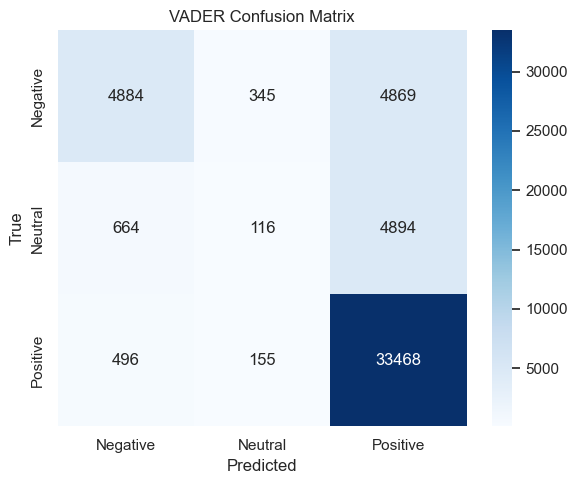

In [4]:
#Vader model
vader = VADERSentimentModel()
vader_preds, vader_infer_time = vader.timed_predict(X_test)
vader_results = sentiment_report(y_test, vader_preds, model_name='VADER')
vader_results['train_time'] = 0.0
vader_results['infer_time'] = vader_infer_time

plot_confusion_matrix(
    y_test, vader_preds, ['Negative', 'Neutral', 'Positive'],
    title='VADER Confusion Matrix',
    save_path='../data/figures/cm_vader.png'
);


  Logistic Regression
  Accuracy:    0.8559
  F1 (macro):  0.6740
  F1 (weighted): 0.8302
              precision    recall  f1-score   support

    Negative       0.82      0.82      0.82     10098
     Neutral       0.59      0.18      0.28      5674
    Positive       0.88      0.98      0.93     34119

    accuracy                           0.86     49891
   macro avg       0.76      0.66      0.67     49891
weighted avg       0.83      0.86      0.83     49891


Top TF-IDF tokens per class:
  Negative: ['worst', 'no', 'not', 'horrible', 'terrible', 'rude', 'the worst', 'disappointing', 'minutes', 'money']
  Neutral: ['ok', 'but', 'okay', 'however', 'decent', 'wasn', 'not', 'though', 'three stars', 'just ok']
  Positive: ['delicious', 'great', 'amazing', 'excellent', 'best', 'awesome', 'perfect', 'definitely', 'the best', 'love']


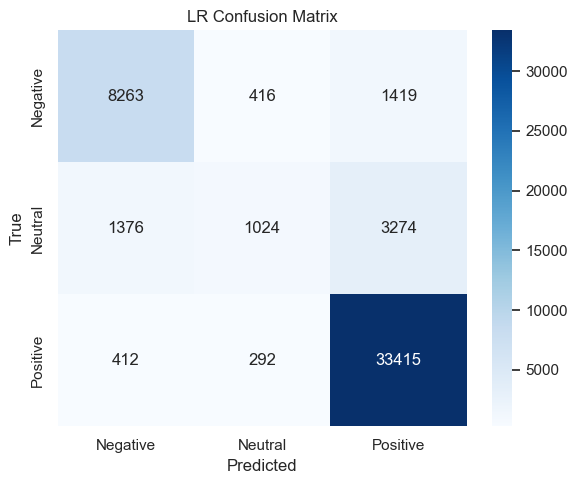

In [ ]:
#LR Model
lr_model = LRSentimentModel(max_features=30_000)
lr_model.fit(X_train_s, y_train_s)
lr_preds, lr_infer_time = lr_model.timed_predict(X_test)
lr_results = sentiment_report(y_test, lr_preds, model_name='LR')
lr_results['train_time'] = lr_model.train_time_
lr_results['infer_time'] = lr_infer_time

plot_confusion_matrix(
    y_test, lr_preds, ['Negative', 'Neutral', 'Positive'],
    title='LR Confusion Matrix',
    save_path='../data/figures/cm_lr.png'
)

print('\ntop TF-IDF/ class:')
for cls, tokens in lr_model.get_top_tfidf_tokens(n=10).items():
    print(f'  {cls}: {tokens}')

  Epoch 1/3  loss=0.8504
  Epoch 2/3  loss=0.7046
  Epoch 3/3  loss=0.6068

  BiLSTM
  Accuracy:    0.7531
  F1 (macro):  0.4936
  F1 (weighted): 0.7108
              precision    recall  f1-score   support

    Negative       0.57      0.62      0.59     10098
     Neutral       0.34      0.02      0.03      5674
    Positive       0.81      0.92      0.86     34119

    accuracy                           0.75     49891
   macro avg       0.57      0.52      0.49     49891
weighted avg       0.71      0.75      0.71     49891



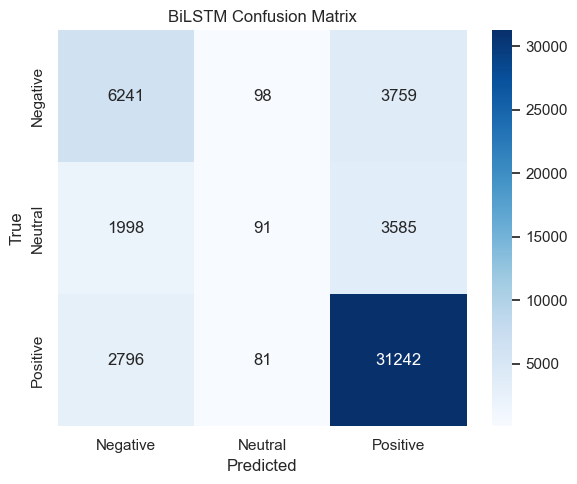

In [6]:
#BiLSTM
lstm_model = LSTMSentimentModel(embed_dim=128, hidden_dim=256, epochs=3, batch_size=128)
lstm_model.fit(X_train_s, y_train_s, val_texts=X_val_s, val_labels=y_val_s)
lstm_preds, lstm_infer_time = lstm_model.timed_predict(X_test)
lstm_results = sentiment_report(y_test, lstm_preds, model_name='BiLSTM')
lstm_results['train_time'] = lstm_model.train_time_
lstm_results['infer_time'] = lstm_infer_time

plot_confusion_matrix(
    y_test, lstm_preds, ['Negative', 'Neutral', 'Positive'],
    title='BiLSTM Confusion Matrix',
    save_path='../data/figures/cm_lstm.png'
);

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/2  loss=0.4633
  Epoch 2/2  loss=0.2974

  BERT
  Accuracy:    0.8674
  F1 (macro):  0.7312
  F1 (weighted): 0.8583
              precision    recall  f1-score   support

    Negative       0.82      0.84      0.83     10098
     Neutral       0.52      0.36      0.42      5674
    Positive       0.92      0.96      0.94     34119

    accuracy                           0.87     49891
   macro avg       0.75      0.72      0.73     49891
weighted avg       0.85      0.87      0.86     49891



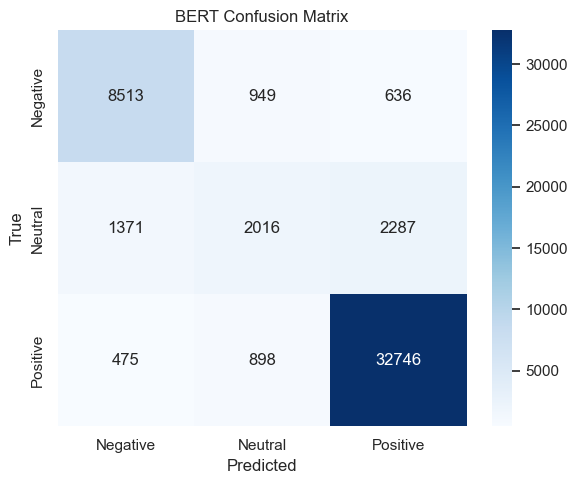

In [7]:
#BERT DistilBERT
bert_model = BERTSentimentModel(model_name='distilbert-base-uncased', epochs=2, batch_size=32)
bert_model.fit(X_train_s, y_train_s)
bert_preds, bert_infer_time = bert_model.timed_predict(X_test)
bert_results = sentiment_report(y_test, bert_preds, model_name='BERT')
bert_results['train_time'] = bert_model.train_time_
bert_results['infer_time'] = bert_infer_time

plot_confusion_matrix(
    y_test, bert_preds, ['Negative', 'Neutral', 'Positive'],
    title='BERT Confusion Matrix',
    save_path='../data/figures/cm_bert.png'
);

                     accuracy  f1_macro  f1_weighted  train_time  infer_time
model                                                                       
VADER                  0.7710    0.5025       0.7185      0.0000     19.8137
Logistic Regression    0.8559    0.6740       0.8302      3.3589      3.7798
BiLSTM                 0.7531    0.4936       0.7108    682.6999    244.1175
BERT                   0.8674    0.7312       0.8583   2723.7746    878.1654


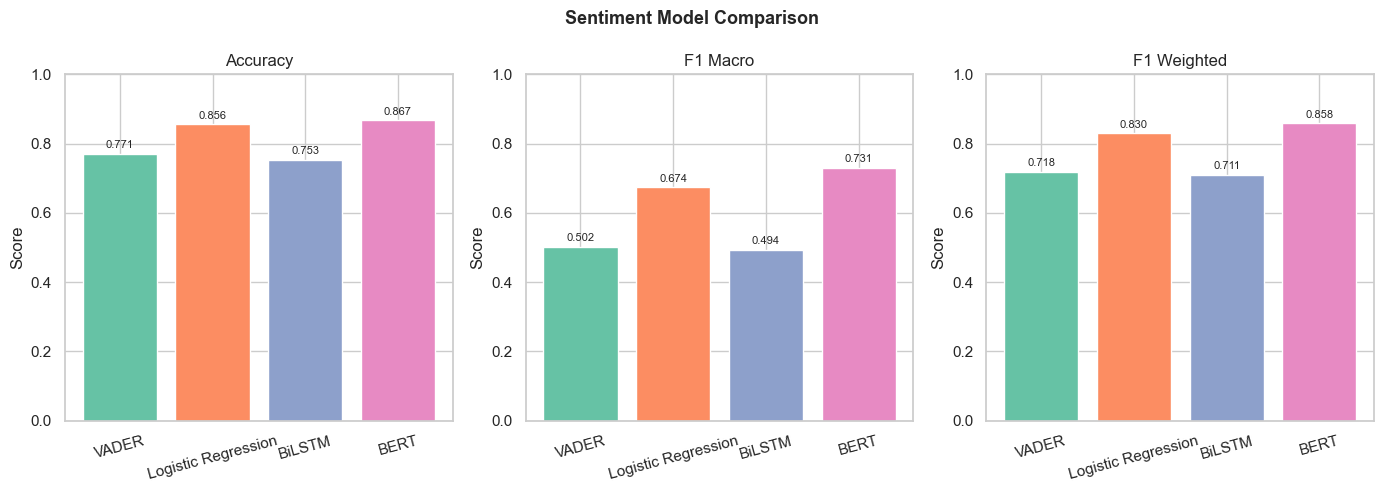

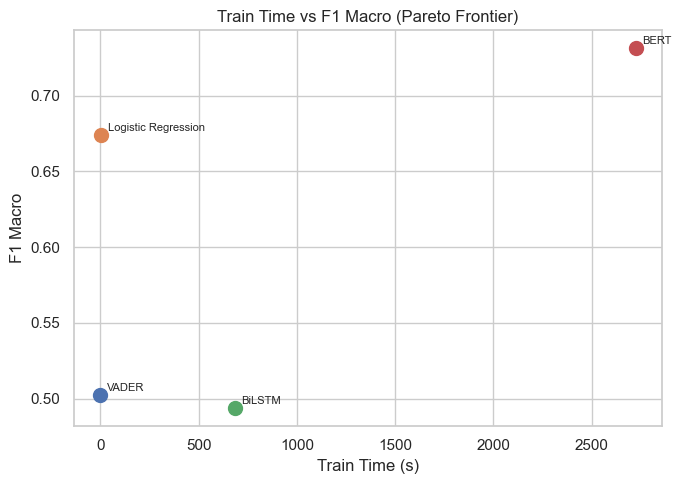

In [8]:
all_results = [vader_results, lr_results, lstm_results, bert_results]

comparison_df = build_comparison_table(all_results)
print(comparison_df[['accuracy', 'f1_macro', 'f1_weighted', 'train_time', 'infer_time']].round(4))

plot_sentiment_model_comparison(all_results, save_path='../data/figures/sentiment_comparison.png');
plot_train_vs_f1(all_results, save_path='../data/figures/pareto_sentiment.png');